<img style="float: left; margin: 30px 15px 15px 15px;" src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="500" height="250" /> 
    
    
# <font color='navy'> Modelo de Puntuación Crediticia

<font color='black'>

- Ivanna herrera Ibarra
- Ana Sofía Hinojosa Bale
- Luis Fernando Márquez Bañuelos

## <font color='royalblue'> Librerías

In [45]:
import shap
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier, plot_importance
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

## <font color='royalblue'> Benchmark

In [19]:
data = pd.read_csv('clean_train.csv')

data['Credit_Score'] = data['Credit_Score'].map({'Poor': 0, 'Standard': 1, 'Good': 2})
data = data.select_dtypes(include=['float64', 'int64', 'bool'])

target = 'Credit_Score'

In [20]:
X = data.copy()
X = X.drop(columns=[target])
y = data[target]

In [21]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

              precision    recall  f1-score   support

           0       0.51      0.55      0.53      5799
           1       0.57      0.74      0.65     10635
           2       0.00      0.00      0.00      3566

    accuracy                           0.55     20000
   macro avg       0.36      0.43      0.39     20000
weighted avg       0.45      0.55      0.50     20000



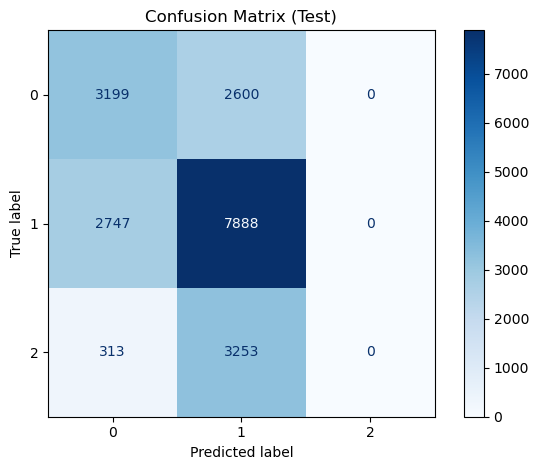

In [22]:
# Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=[0, 1, 2],
    cmap='Blues'
)
plt.title('Confusion Matrix (Test)')

plt.tight_layout()
plt.show()

## <font color='royalblue'> Feature Selection

              precision    recall  f1-score   support

           0       0.77      0.69      0.73      5799
           1       0.74      0.80      0.77     10635
           2       0.64      0.59      0.62      3566

    accuracy                           0.73     20000
   macro avg       0.72      0.70      0.71     20000
weighted avg       0.73      0.73      0.73     20000



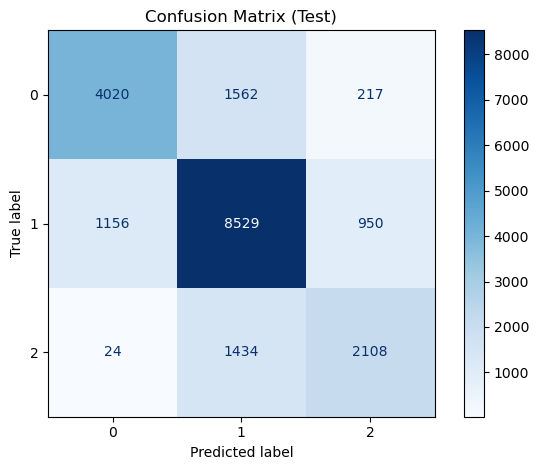

In [26]:
model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=500,
    max_depth=8,
    learning_rate=0.01,
    min_child_weight=3,
    subsample=0.6,
    colsample_bytree=0.6,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=0
)

y_pred_xgb = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred_xgb))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=[0, 1, 2],
    cmap='Blues'
)
plt.title('Confusion Matrix (Test)')

plt.tight_layout()
plt.show()

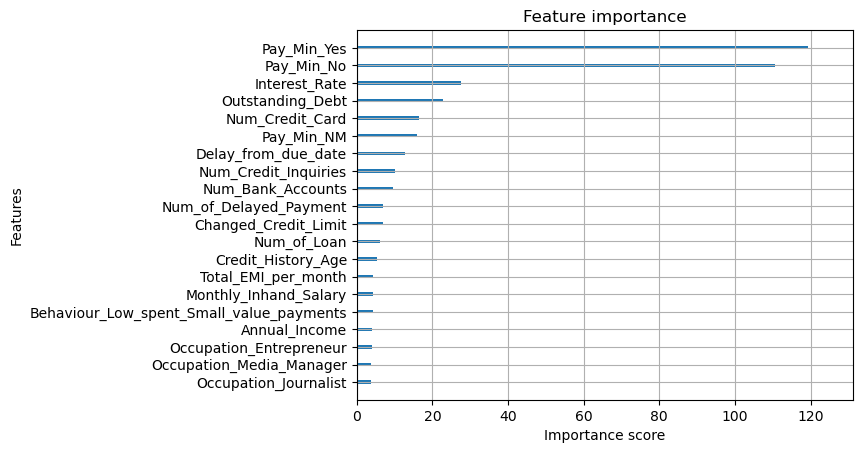

In [43]:
plot_importance(model, max_num_features=20, importance_type='gain', show_values=False);

In [46]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

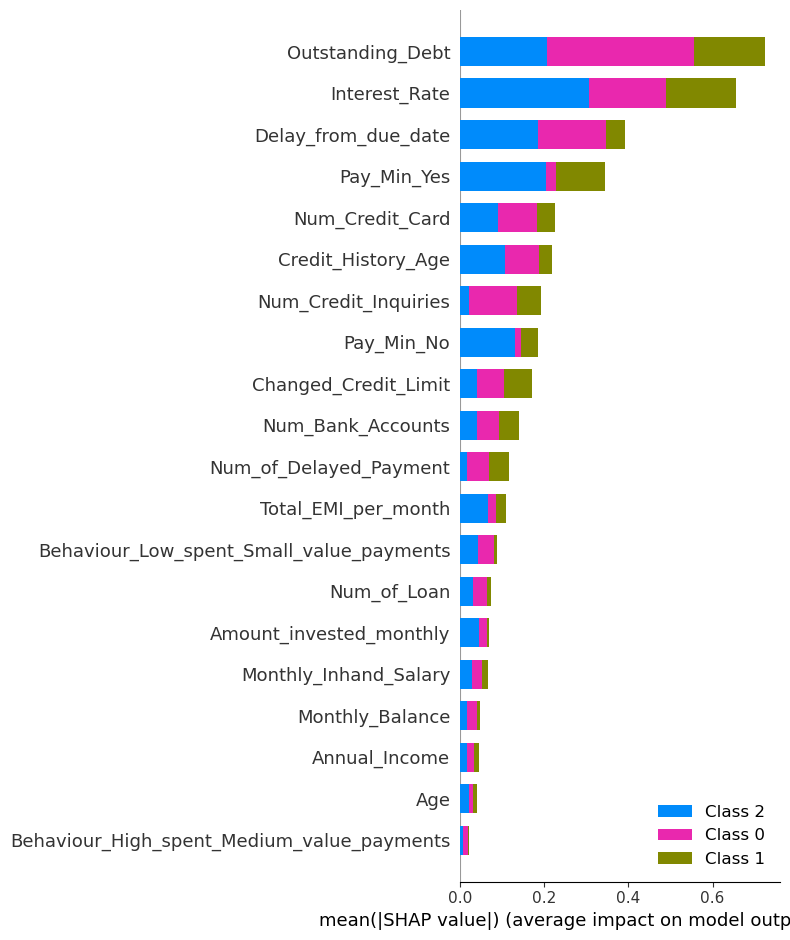

In [57]:
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20)

In [55]:
print("Verificando estructura de SHAP values...")
print(f"Tipo: {type(shap_values)}")

# Caso 1: Lista de arrays (un array por clase)
if isinstance(shap_values, list):
    print(f"Número de clases: {len(shap_values)}")
    print(f"Shape de cada clase: {shap_values[0].shape}")
    # Ya está en el formato correcto
    
# Caso 2: Array 3D (n_samples, n_features, n_classes)
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    print(f"Shape original: {shap_values.shape}")
    # Convertir a lista de arrays (transponer)
    shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
    print(f"Convertido a lista de {len(shap_values)} arrays")
    print(f"Shape de cada clase: {shap_values[0].shape}")

Verificando estructura de SHAP values...
Tipo: <class 'numpy.ndarray'>
Shape original: (20000, 52, 3)
Convertido a lista de 3 arrays
Shape de cada clase: (20000, 52)



SHAP SUMMARY - Poor Credit Score


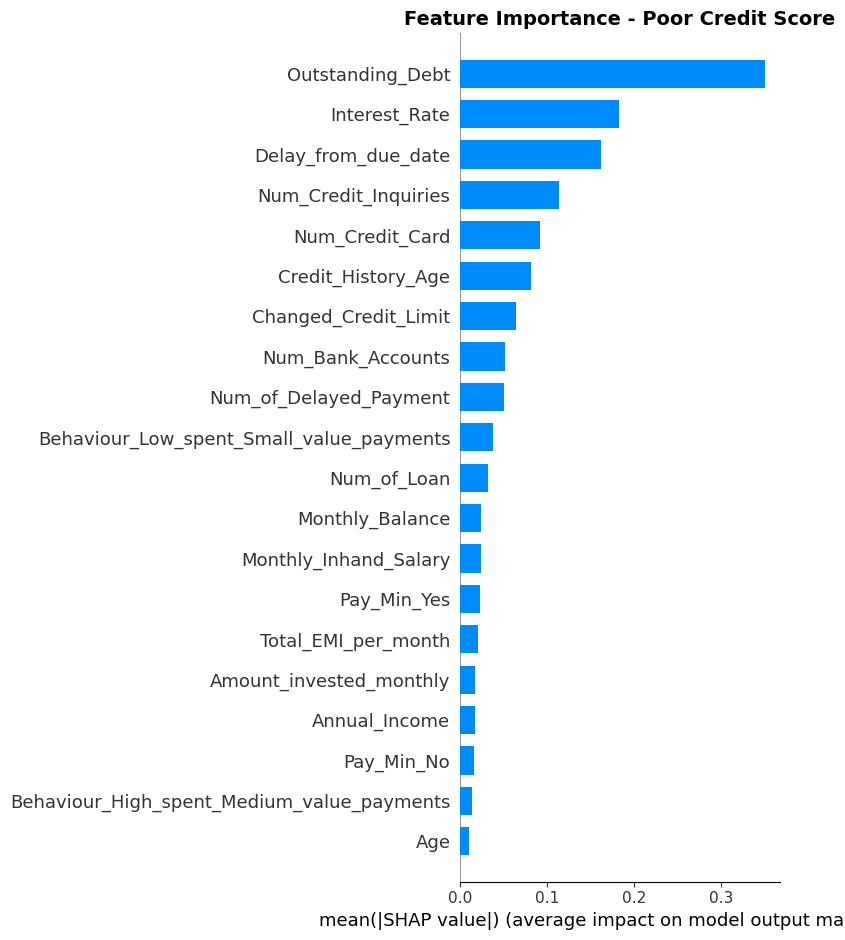

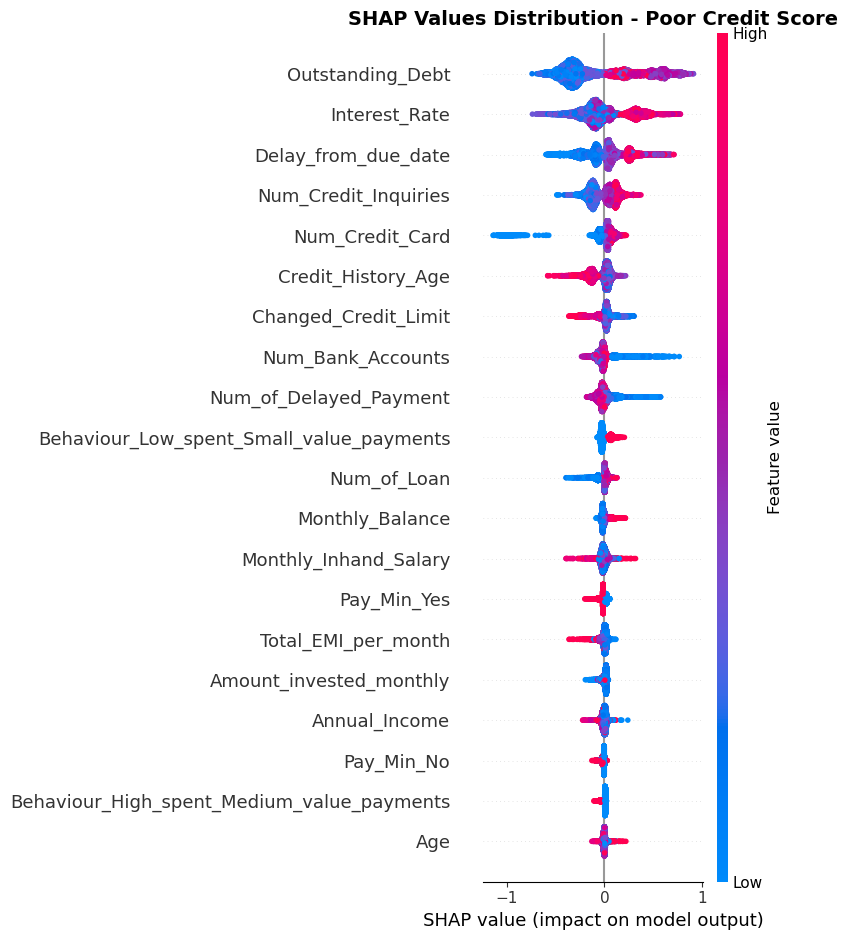


SHAP SUMMARY - Standard Credit Score


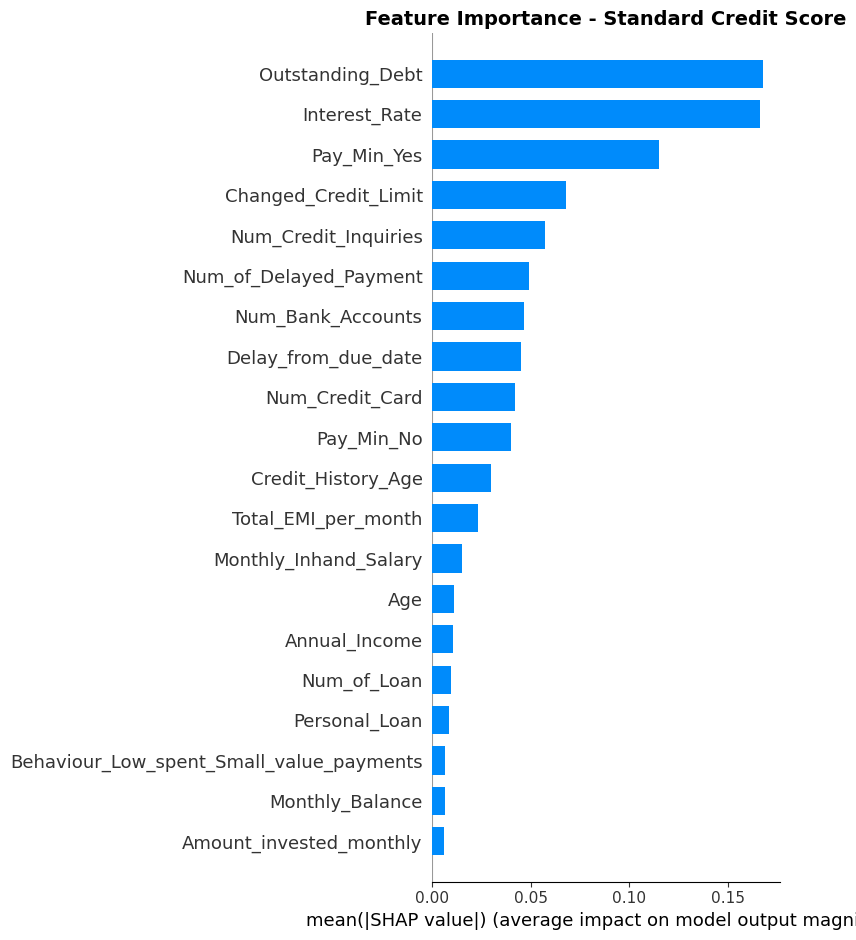

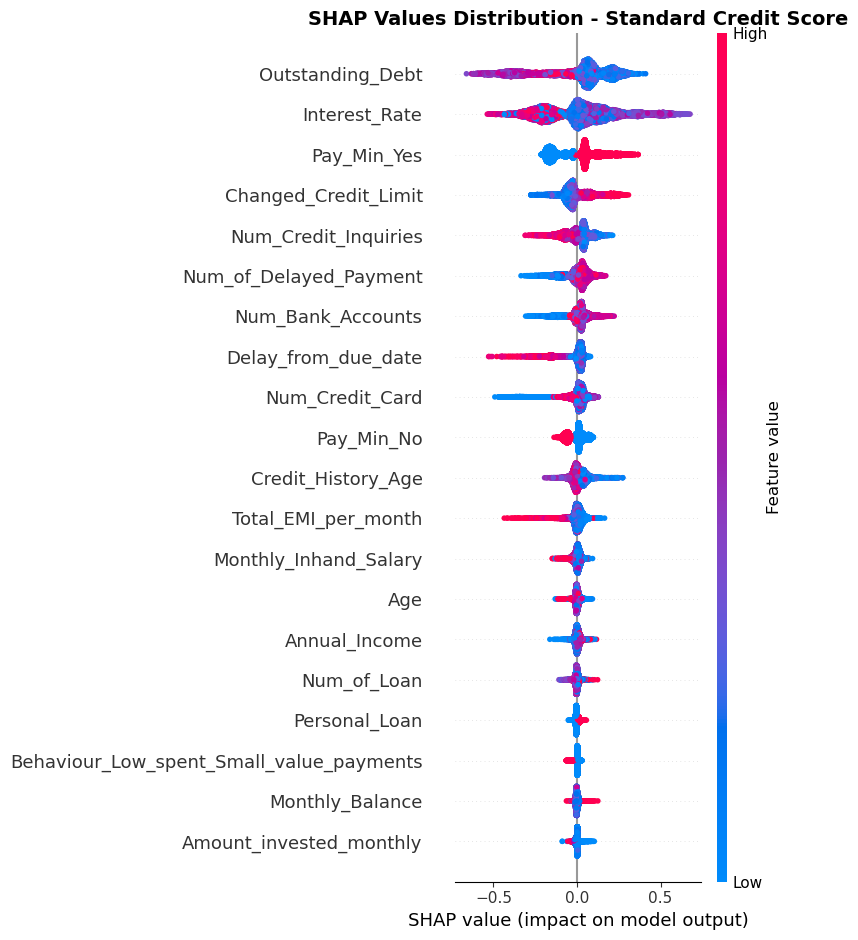


SHAP SUMMARY - Good Credit Score


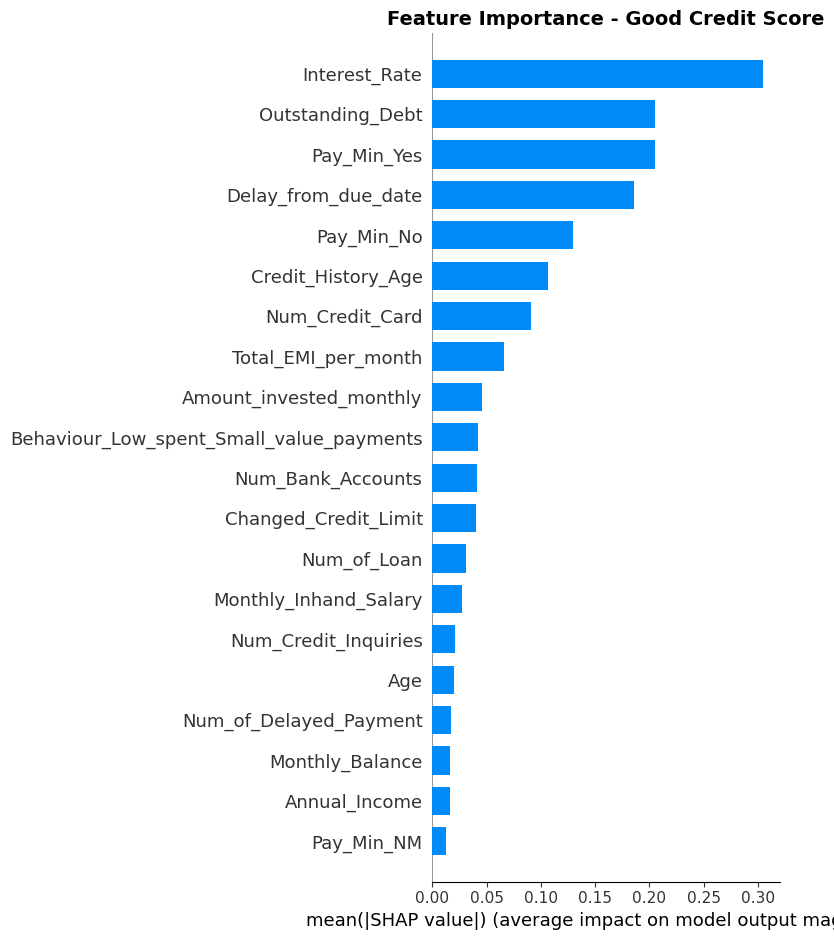

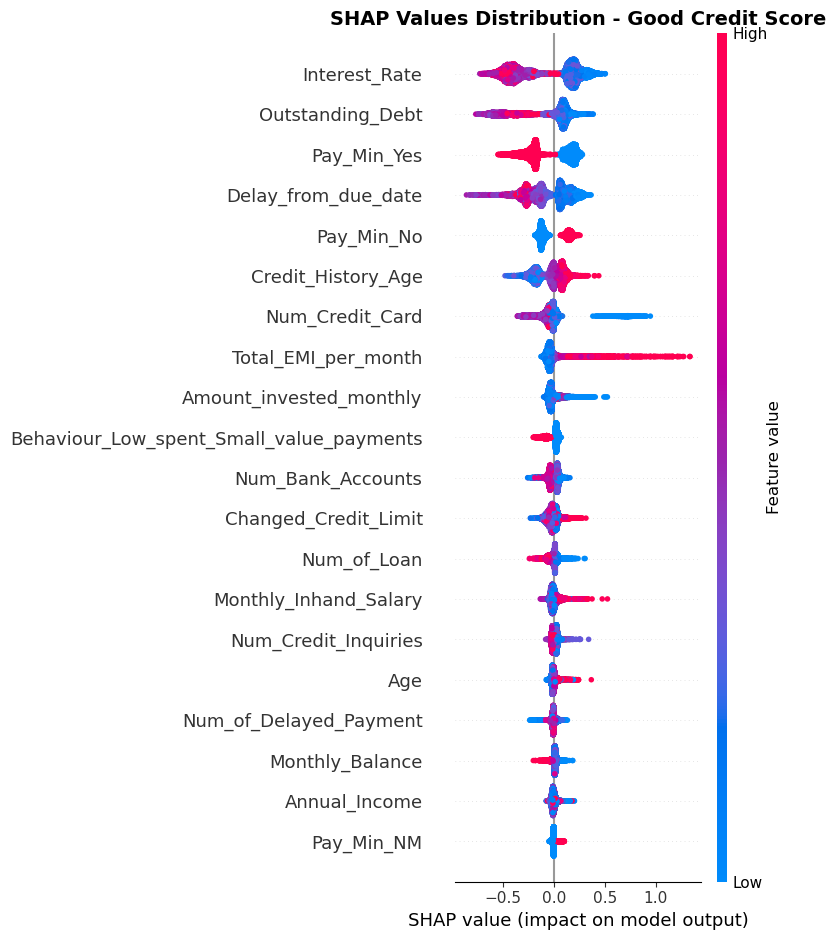

In [58]:
class_names = ['Poor', 'Standard', 'Good']

for i, class_name in enumerate(class_names):
    print(f"\n{'='*60}")
    print(f"SHAP SUMMARY - {class_name} Credit Score")
    print(f"{'='*60}")
    
    # Bar plot - importancia absoluta
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values[i], 
                     X_test,
                     plot_type="bar",
                     max_display=20,
                     show=False)
    plt.title(f'Feature Importance - {class_name} Credit Score', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Beeswarm plot - dirección del efecto
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values[i], 
                     X_test,
                     max_display=20,
                     show=False)
    plt.title(f'SHAP Values Distribution - {class_name} Credit Score', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()